# Q1 2026 Yield Curve Review  
### Regime Signals, Drivers, and Market Implications

## Introduction

A yield curve plots the interest rates of bonds with equal credit quality across different maturities. It reflects market expectations for future interest rates, inflation, and economic growth.

The U.S. Treasury yield curve is widely used as a benchmark for financial markets and plays a key role in signaling economic conditions.

### Why It Matters
- The slope predicts economic expansion or contraction
- It reflects expectations about Federal Reserve policy
- It influences lending, mortgages, and financial conditions

### Objective

This notebook analyzes the U.S. Treasury yield curve during Q1 2026 to:
- Examine changes in curve shape
- Analyze key spreads (10Y–2Y, 10Y–3M)
- Decompose the curve using PCA (Level, Slope, Curvature)
- Interpret macroeconomic implications


## Yield Curve Framework

The shape of the yield curve provides insights into economic expectations:

### 1. Normal (Upward Sloping)
- Long-term yields > short-term yields
- Signals economic expansion

### 2. Inverted (Downward Sloping)
- Short-term yields > long-term yields
- Historically signals recession risk

### 3. Flat Curve
- Similar yields across maturities
- Indicates economic uncertainty

### 4. Steep Curve
- Large gap between short and long-term yields
- Suggests strong growth and inflation expectations

### 5. Humped Curve
- Medium-term yields higher than others
- Often reflects transitional conditions



## 2. Data (FRED)

In [4]:
!pip install fredapi scikit-learn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from fredapi import Fred
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

fred = Fred(api_key="4c9bd221409ce3528775c875ab1222b4")

series = {
    "3M": "DGS3MO",
    "2Y": "DGS2",
    "5Y": "DGS5",
    "7Y": "DGS7",
    "10Y": "DGS10",
    "30Y": "DGS30"
}

start = "2025-12-31"
end = "2026-03-31"

df = pd.DataFrame()
for k, v in series.items():
    df[k] = fred.get_series(v, observation_start=start, observation_end=end)

df = df.dropna()
df.head()

,3M,2Y,5Y,7Y,10Y,30Y
2025-12-31,3.67,3.47,3.73,3.94,4.18,4.84
2026-01-02,3.65,3.47,3.74,3.95,4.19,4.86
2026-01-05,3.64,3.46,3.71,3.92,4.17,4.85
2026-01-06,3.63,3.47,3.72,3.93,4.18,4.86
2026-01-07,3.62,3.47,3.70,3.91,4.15,4.82


## 4. Yield Curve Snapshot (SHAPE ANALYSIS)

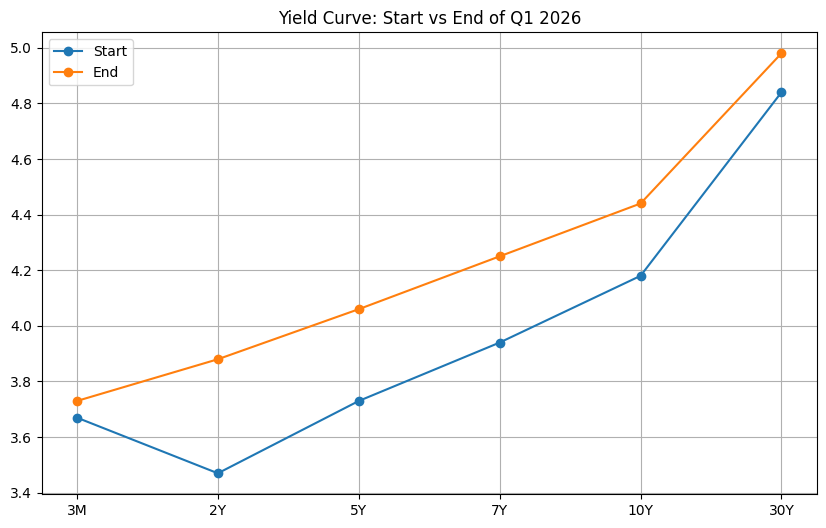

In [5]:
start_curve = df.iloc[0]
end_curve = df.iloc[-1]

maturities = ["3M","2Y","5Y","7Y","10Y","30Y"]

plt.figure(figsize=(10,6))
plt.plot(maturities, start_curve[maturities], marker='o', label="Start")
plt.plot(maturities, end_curve[maturities], marker='o', label="End")
plt.title("Yield Curve: Start vs End of Q1 2026")
plt.legend()
plt.grid(True)
plt.show()

### Curve Classification

The yield curve comparison between the start and end of Q1 2026 shows a clear shift in the level and shape of rates.

### Key Observations

- The curve is **upward sloping across all maturities** at both the start and end of the quarter  
- At the start of Q1, there was a **mild front-end inversion** (3M > 2Y)  
- By the end of Q1, this inversion **disappears**, and the curve becomes more uniformly upward sloping  

### Level Shift

- Yields increased across **all maturities** over the quarter  
- This represents a **parallel upward shift** in the yield curve  

### Classification

The curve transitions from:

**“Upward sloping with a front-end kink” → “Clean upward sloping (normalized)”**

### Interpretation

- The removal of the front-end inversion suggests that **near-term policy expectations have adjusted upward**, aligning more closely with the rest of the curve  
- The overall upward shift indicates:
  - stronger inflation expectations  
  - higher term premium  
  - or a repricing of the expected path of interest rates  

### Economic Signal

This evolution suggests a **normalization of the yield curve structure**:

- Early Q1 → mixed signals (tight policy vs longer-term expectations)  
- End of Q1 → more consistent upward slope  

This is typically associated with:
- reduced recession signaling  
- more stable or resilient macro expectations  

Overall, the yield curve movement during Q1 2026 reflects a transition toward a more coherent market view of interest rates across maturities.


## 5. Spread Analysis (MACRO SIGNAL)

### 5.1 Computing Key Yield Curve Spreads

In [6]:
# Compute key spreads
df["10Y-2Y"] = df["10Y"] - df["2Y"]
df["10Y-3M"] = df["10Y"] - df["3M"]
df["2Y-3M"] = df["2Y"] - df["3M"]

# Preview the first few rows
df[["10Y-2Y", "10Y-3M", "2Y-3M"]].head()

,10Y-2Y,10Y-3M,2Y-3M
2025-12-31,0.71,0.51,-0.20
2026-01-02,0.72,0.54,-0.18
2026-01-05,0.71,0.53,-0.18
2026-01-06,0.71,0.55,-0.16
2026-01-07,0.68,0.53,-0.15


### 5.2 Summary Statistics for Spreads

In [7]:
# Summary statistics
df[["10Y-2Y", "10Y-3M", "2Y-3M"]].describe()

,10Y-2Y,10Y-3M,2Y-3M
count,60.000000,60.000000,60.000000
mean,0.622000,0.502333,-0.119667
std,0.077892,0.097082,0.118536
min,0.460000,0.300000,-0.290000
25%,0.560000,0.425000,-0.200000
50%,0.620000,0.530000,-0.140000
75%,0.700000,0.570000,-0.095000
max,0.740000,0.710000,0.230000


### 5.3 Plotting Spread Dynamics Over Q1 2026

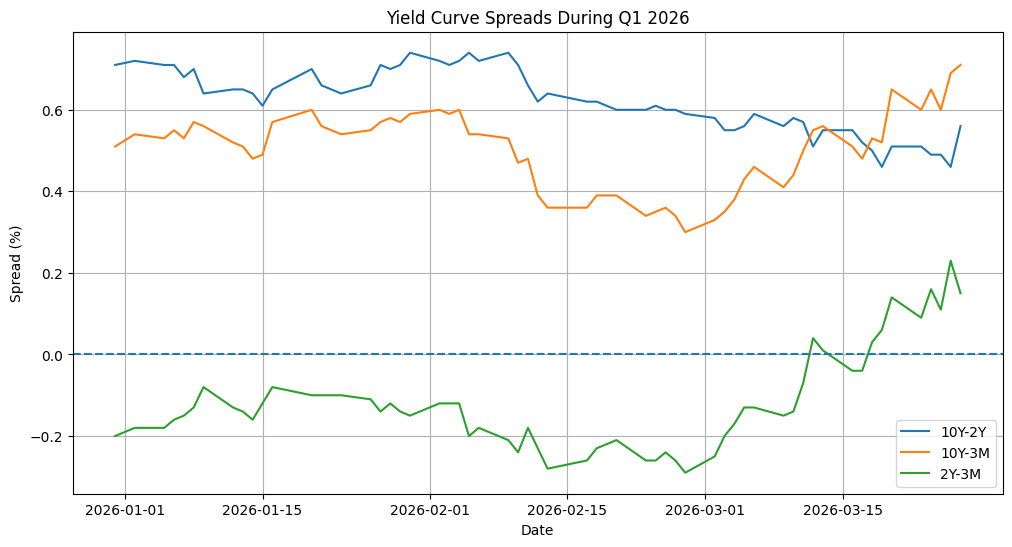

In [8]:
plt.figure(figsize=(12,6))
plt.plot(df.index, df["10Y-2Y"], label="10Y-2Y")
plt.plot(df.index, df["10Y-3M"], label="10Y-3M")
plt.plot(df.index, df["2Y-3M"], label="2Y-3M")
plt.axhline(0, linestyle="--")
plt.title("Yield Curve Spreads During Q1 2026")
plt.xlabel("Date")
plt.ylabel("Spread (%)")
plt.legend()
plt.grid(True)
plt.show()

### 5.4 Comparing Start vs End of Quarter Spreads

In [9]:
spread_summary = pd.DataFrame({
    "Start of Q1": [
        df["10Y-2Y"].iloc[0],
        df["10Y-3M"].iloc[0],
        df["2Y-3M"].iloc[0]
    ],
    "End of Q1": [
        df["10Y-2Y"].iloc[-1],
        df["10Y-3M"].iloc[-1],
        df["2Y-3M"].iloc[-1]
    ]
}, index=["10Y-2Y", "10Y-3M", "2Y-3M"])

spread_summary

,Start of Q1,End of Q1
10Y-2Y,0.71,0.56
10Y-3M,0.51,0.71
2Y-3M,-0.20,0.15


### 5.5 Showing Spread Changes in Basis Points

In [10]:
spread_change_bps = (spread_summary["End of Q1"] - spread_summary["Start of Q1"]) * 100
spread_change_bps.to_frame(name="Change (bps)")

,Change (bps)
10Y-2Y,-15.0
10Y-3M,20.0
2Y-3M,35.0


### Spread Interpretation

Yield curve spreads provide a clearer view of slope dynamics across different segments of the curve.

### Start of Q1 2026

At the beginning of the quarter:

- **10Y–2Y = 0.71%**
- **10Y–3M = 0.51%**
- **2Y–3M = -0.20%**

This indicates that the curve was **not fully inverted**.

- The **10Y–2Y** and **10Y–3M** spreads were positive, confirming an upward-sloping structure across intermediate and long maturities.
- The **2Y–3M** spread was negative, revealing a **localized front-end inversion** driven by elevated short-term rates.

### Evolution During Q1 2026

Spread dynamics over the quarter show a clear transition:

- **10Y–2Y narrowed by ~15 bps** (0.71% → 0.56%)
- **10Y–3M widened by ~20 bps** (0.51% → 0.71%)
- **2Y–3M increased by ~35 bps**, shifting from **-0.20% to +0.15%**

Time-series behavior confirms that:

- Long-end spreads (**10Y–2Y, 10Y–3M**) remained **consistently positive** throughout the quarter
- The front-end spread (**2Y–3M**) was initially negative, reached its most inverted levels mid-quarter, and then **steadily reversed**, crossing into positive territory by mid-March

### What This Means

- The persistent positivity of long-end spreads indicates that the broader yield curve maintained a **stable upward slope**, with markets continuing to price growth, inflation expectations, and term premium.
- The front-end inversion was **temporary and dynamic**, reflecting short-term policy tightness rather than a structural inversion of the curve.

### Structural Shift

By the end of Q1:

- The front-end inversion had **fully disappeared**
- The curve transitioned into a **more uniformly upward-sloping structure**
- Spread behavior became more aligned across maturities

### Macro Takeaway

Taken together, the spread behavior suggests that Q1 2026 was a period of **yield curve normalization rather than persistent inversion**.

- Early Q1 → localized front-end inversion driven by restrictive monetary policy  
- Mid Q1 → peak dislocation at the front end  
- Late Q1 → re-alignment and normalization as spreads converged  

This evolution reflects a **transition in market expectations**, where short-term policy tightness gradually gave way to a more coherent pricing of interest rates across the curve.

Overall, the data points to a **healing term structure**, rather than a classic recessionary signal driven by broad-based inversion.

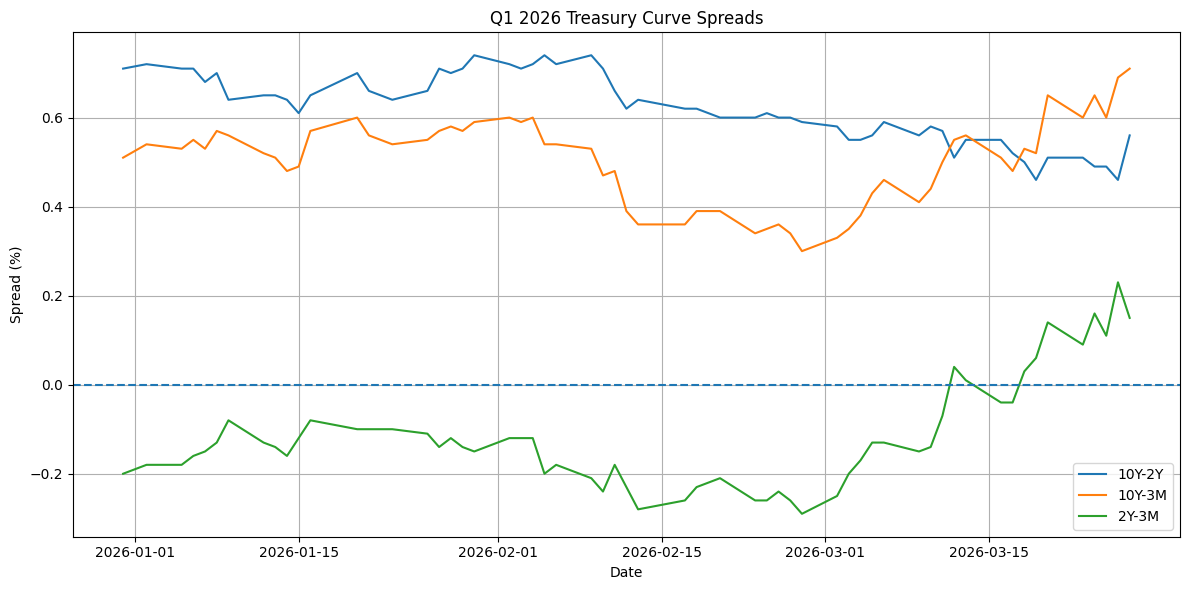

In [12]:
plt.figure(figsize=(12,6))
plt.plot(df.index, df["10Y-2Y"], label="10Y-2Y")
plt.plot(df.index, df["10Y-3M"], label="10Y-3M")
plt.plot(df.index, df["2Y-3M"], label="2Y-3M")
plt.axhline(0, linestyle="--")
plt.title("Q1 2026 Treasury Curve Spreads")
plt.xlabel("Date")
plt.ylabel("Spread (%)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("q1_2026_treasury_spreads.png", dpi=300)
plt.show()

## 6. PCA Decomposition

### 6.1 Preparing Yield Curve Data

In [13]:
curve = df[maturities]
curve.head()

,3M,2Y,5Y,7Y,10Y,30Y
2025-12-31,3.67,3.47,3.73,3.94,4.18,4.84
2026-01-02,3.65,3.47,3.74,3.95,4.19,4.86
2026-01-05,3.64,3.46,3.71,3.92,4.17,4.85
2026-01-06,3.63,3.47,3.72,3.93,4.18,4.86
2026-01-07,3.62,3.47,3.70,3.91,4.15,4.82


### 6.2 Standardizing the Data

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled = scaler.fit_transform(curve)

### 6.3 Applying PCA

In [15]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3)
pcs = pca.fit_transform(scaled)

pca_df = pd.DataFrame(
    pcs,
    columns=["Level", "Slope", "Curvature"],
    index=df.index
)

pca_df.head()

,Level,Slope,Curvature
2025-12-31,-0.679909,-0.871005,-0.369104
2026-01-02,-0.621137,-1.584597,-0.162379
2026-01-05,-1.103011,-1.768318,-0.014696
2026-01-06,-0.982312,-2.121301,0.140088
2026-01-07,-1.551220,-2.137989,0.559269


### 6.4 Explained Variance

In [16]:
explained_var = pd.DataFrame({
    "Component": ["Level (PC1)", "Slope (PC2)", "Curvature (PC3)"],
    "Variance Explained": pca.explained_variance_ratio_
})

explained_var

,Component,Variance Explained
0,Level (PC1),0.808508
1,Slope (PC2),0.162962
2,Curvature (PC3),0.019141


### 6.5 Plot Yield Curve Factors

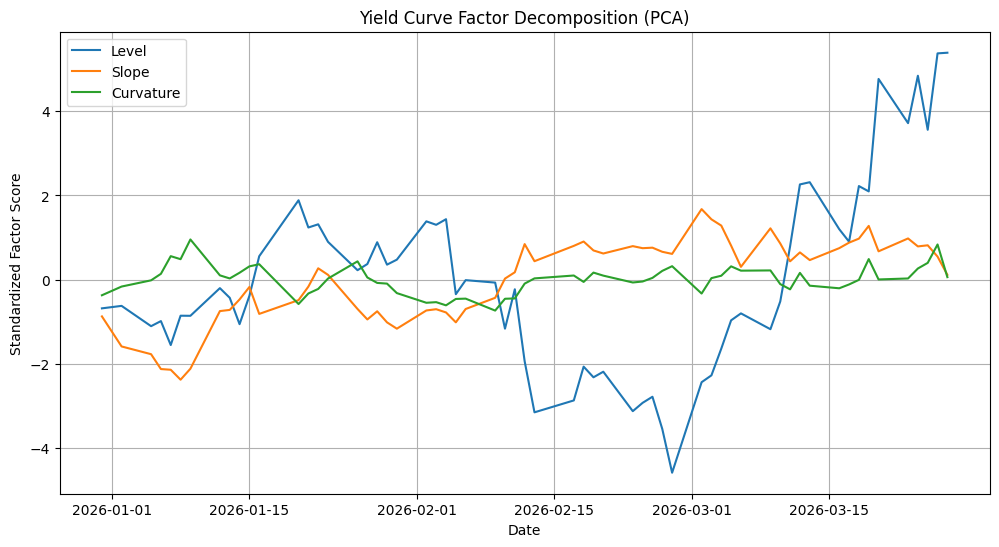

In [17]:
plt.figure(figsize=(12,6))
plt.plot(pca_df["Level"], label="Level")
plt.plot(pca_df["Slope"], label="Slope")
plt.plot(pca_df["Curvature"], label="Curvature")
plt.legend()
plt.title("Yield Curve Factor Decomposition (PCA)")
plt.xlabel("Date")
plt.ylabel("Standardized Factor Score")
plt.grid(True)
plt.show()

### 6.6  Term Structure Dynamics (PCA Results)

### Term Structure Interpretation

Principal Component Analysis (PCA) decomposes the yield curve into three key factors that summarize its movement over time.

### Factor Definitions

- **Level (PC1):** Captures parallel shifts in yields across all maturities  
- **Slope (PC2):** Captures changes between short-term and long-term rates  
- **Curvature (PC3):** Captures movements in intermediate maturities relative to the front and long end  

### Explained Variance

- **Level (PC1): ~80.9%**
- **Slope (PC2): ~16.3%**
- **Curvature (PC3): ~1.9%**

This indicates that the vast majority of yield curve variation during Q1 2026 was driven by **parallel shifts in interest rates**, with slope changes playing a secondary role and curvature contributing minimally.

### Observed Factor Dynamics

- **Level (PC1):**
  - Exhibits the largest movement over the quarter  
  - Declines sharply into mid-February before reversing strongly into March  
  - Ends at its highest levels, indicating a broad upward shift in yields  

- **Slope (PC2):**
  - Starts negative and trends upward over time  
  - Turns positive and remains elevated toward the end of the quarter  
  - Reflects a gradual steepening and normalization of the curve  

- **Curvature (PC3):**
  - Remains close to zero throughout  
  - Shows relatively small fluctuations compared to Level and Slope  
  - Indicates limited structural change in intermediate maturities  

### Link to Spread Dynamics

The PCA results are consistent with earlier spread analysis:

- The dominance of the **Level factor** aligns with the observed **parallel upward shift in yields** across maturities  
- The upward movement in the **Slope factor** reflects the **normalization of the front end**, as the 2Y–3M spread moved from negative to positive  
- The minimal role of **Curvature** confirms that the yield curve changes were not driven by distortions in the belly, but rather by broad and front-end adjustments  

### Interpretation

Taken together, the PCA decomposition suggests that Q1 2026 yield curve dynamics were driven primarily by:

- A **broad repricing of interest rates (Level shift)**  
- A **gradual steepening and alignment of the curve (Slope normalization)**  
- Limited structural changes in intermediate maturities (low Curvature impact)  

These dynamics reinforce the conclusion that the yield curve underwent **normalization rather than structural inversion**, with movements concentrated in overall rate levels and front-end adjustments.

### Factor Loadings (Technical Validation)

In [18]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=maturities,
    columns=["Level", "Slope", "Curvature"]
)

loadings

,Level,Slope,Curvature
3M,0.236458,0.848012,-0.472003
2Y,0.419969,0.284278,0.676912
5Y,0.450624,-0.053411,0.206078
7Y,0.448906,-0.113428,0.036862
10Y,0.442485,-0.204489,-0.183007
30Y,0.409075,-0.377528,-0.491614


### Factor Loadings Interpretation

The PCA loadings validate the standard interpretation of yield curve factors:

- Level loads positively across maturities → parallel shifts  
- Slope contrasts short vs long maturities → steepening/flattening  
- Curvature emphasizes intermediate maturities → belly movements  

This confirms that the PCA decomposition aligns with the economic interpretation used in the analysis.

## 7. Macro Interpretation

### 1. Curve Shape

The yield curve during Q1 2026 was **not structurally inverted**, but instead exhibited a **transition from a front-end kink to a fully upward-sloping curve**.

- Early Q1:
  - Mild front-end inversion (3M > 2Y)  
  - Positive long-end spreads (10Y–2Y, 10Y–3M)  

- End of Q1:
  - Front-end inversion fully reversed (2Y–3M turned positive)  
  - Curve became **uniformly upward sloping across maturities**

This indicates that the curve evolved from a **segmented structure → coherent term structure** over the quarter.

---

### 2. Policy Expectations

Short-term yields initially reflected **restrictive Federal Reserve policy**, as seen in the front-end inversion early in the quarter.

However, spread dynamics show that:

- The **2Y–3M spread increased by ~35 bps**, moving from negative to positive  
- This suggests that **near-term rate expectations adjusted upward**, reducing the distortion at the front end  

At the same time:

- Long-end spreads remained consistently positive  
- This indicates that **medium- and long-term expectations for growth and inflation remained stable**

---

### 3. Market Narrative

The data points to a clear **transition in market expectations** during Q1 2026:

- Early Q1:
  - Tight policy conditions dominating short-term rates  
  - Localized dislocation at the front end  

- Mid Q1:
  - Peak front-end inversion and dispersion  

- Late Q1:
  - Re-alignment of short-term rates with the broader curve  
  - Emergence of a **clean upward-sloping structure**

PCA results reinforce this narrative:

- **Level (≈81% variance):** dominant driver → broad repricing of rates  
- **Slope (≈16%):** reflects **front-end normalization and steepening dynamics**  
- **Curvature (~2%):** minimal → no significant distortion in the belly  

---

### 4. Signal Interpretation

While yield curve inversion has historically been a strong recession signal, the Q1 2026 data suggests a more nuanced interpretation:

- The curve was **never fully inverted across key spreads**
- The front-end inversion was **temporary and reversed within the quarter**
- Long-end spreads remained **consistently positive**

This weakens the traditional recession signal and instead suggests:

 A **normalization regime**, rather than persistent inversion  

---

### 5. Macro Takeaway

Overall, the yield curve behavior in Q1 2026 reflects:

- A **broad upward shift in rates (Level effect)**  
- A **resolution of front-end dislocation (Slope normalization)**  
- A **stable term structure across intermediate and long maturities**

This combination points to a market transitioning from:

**restrictive policy conditions → more aligned and coherent rate expectations**

## 8. Conclusion

### Key Takeaways

1. The Q1 2026 yield curve was **not structurally inverted**, but showed a **temporary front-end inversion that fully reversed over the quarter**  

2. Long-end spreads (10Y–2Y, 10Y–3M) remained **consistently positive**, confirming a stable upward-sloping term structure  

3. The **2Y–3M spread increased by ~35 bps**, moving from negative to positive, indicating a **normalization of short-term rate expectations**  

4. PCA analysis confirms that:
   - Yield curve dynamics were driven primarily by **Level shifts (~81%)**
   - **Slope changes (~16%)** captured front-end normalization  
   - **Curvature (~2%)** played a minimal role  

---

### Market Implications

- The reversal of front-end inversion suggests that **policy expectations became more aligned with the broader curve**  

- The persistence of positive long-end spreads indicates that **markets continue to price stable growth and inflation expectations**  

- The dominance of Level shifts reflects a **broad repricing of interest rates**, rather than isolated distortions  

---

### Final Insight

Q1 2026 can be characterized as a period of **yield curve normalization**, where:

- Initial front-end distortions driven by restrictive policy  
→ transitioned into  
- A more coherent and upward-sloping term structure  

This behavior suggests a market environment that is **adjusting and stabilizing**, rather than signaling a classic recessionary regime driven by sustained inversion.